In [ ]:
## importing necessary Libraries for DA & v 

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data interpretation 

In [4]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [5]:
df.Pclass.unique().tolist()

[3, 1, 2]

In [6]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


Types Of Features


Categorical Features:
A categorical variable is one that has two or more categories and each value in that feature can be categorised by them.For example, gender is a categorical variable having two categories (male and female). Now we cannot sort or give any ordering to such variables. They are also known as Nominal Variables.


Categorical Features in the dataset: Sex,Embarked.


Ordinal Features:
An ordinal variable is similar to categorical values, but the difference between them is that we can have relative ordering or sorting between the values. For eg: If we have a feature like Height with values Tall, Medium, Short, then Height is a ordinal variable. Here we can have a relative sort in the variable. Ordinal Features in the dataset: PClass


Continous Feature:
A feature is said to be continous if it can take values between any two points or between the minimum or maximum values in the features column.


is PassengerID, Name , Ticket of any importance?

In [8]:
df.drop(["PassengerId", "Ticket","Name"],axis = 1, inplace = True)

In [11]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin',
       'Embarked'],
      dtype='object')

##Let us find the Imbalance % age of Survived 

SyntaxError: invalid syntax (3882102576.py, line 1)

In [15]:
df.Survived.value_counts()

0    549
1    342
Name: Survived, dtype: int64

In [17]:
df.Survived.value_counts(normalize=True)

0    0.616162
1    0.383838
Name: Survived, dtype: float64

In [18]:
df.Survived.value_counts(normalize=True)*100

0    61.616162
1    38.383838
Name: Survived, dtype: float64

In [21]:
#let us find the Imbalance %age in 
"Survived"
"Pclass"
"Sex"
"Embarked"

'Embarked'

In [23]:
select_columns = ["Survived","Pclass","Sex","Embarked"]


In [29]:
for column in select_columns:
    print(df[column].value_counts())
    print("_"*60)
    print(df[column].value_counts(normalize=True)*100)
    print("*"*60)

0    549
1    342
Name: Survived, dtype: int64
____________________________________________________________
0    61.616162
1    38.383838
Name: Survived, dtype: float64
************************************************************
3    491
1    216
2    184
Name: Pclass, dtype: int64
____________________________________________________________
3    55.106622
1    24.242424
2    20.650954
Name: Pclass, dtype: float64
************************************************************
male      577
female    314
Name: Sex, dtype: int64
____________________________________________________________
male      64.758698
female    35.241302
Name: Sex, dtype: float64
************************************************************
S    644
C    168
Q     77
Name: Embarked, dtype: int64
____________________________________________________________
S    72.440945
C    18.897638
Q     8.661417
Name: Embarked, dtype: float64
************************************************************


In [30]:
#ther is dupllicate the records in data lets delete it.


In [31]:
df.shape

(891, 9)

In [32]:
df.drop_duplicates(inplace=True)


In [33]:
df.shape

(784, 9)

In [34]:
#Missing Value Treatment



In [35]:
df.isna().sum().sort_values(ascending = False)

Cabin       581
Age         106
Embarked      2
Survived      0
Pclass        0
Sex           0
SibSp         0
Parch         0
Fare          0
dtype: int64

In [36]:
#To understand the Impact of Missing values on DAta let us concert the 
#count in %age

In [37]:
round(df.isna().mean()*100,2)

Survived     0.00
Pclass       0.00
Sex          0.00
Age         13.52
SibSp        0.00
Parch        0.00
Fare         0.00
Cabin       74.11
Embarked     0.26
dtype: float64

In [41]:
#Noes:
#we have ?%age of missing data in cabin 
#we have 13% of missing data in age
#we have .26% of missing data in Embarked 

In [ ]:
Treatment Suggestions

- if missing %age > 40 then delete the column


- if missing %age < 5 then drop the rows containing missing values.


In [ ]:
#cabin Attributes
df.drop("Cabin", axis = 1, inplace = True)


In [42]:
#Embraked Attributes 
df.dropna(subset=["Embarked"],inplace = True)


In [43]:
#Age Attributes #13.52% missing values.
#13.52 is big data so we can not delete the data 




In [44]:
#Impute the values | Median and mean

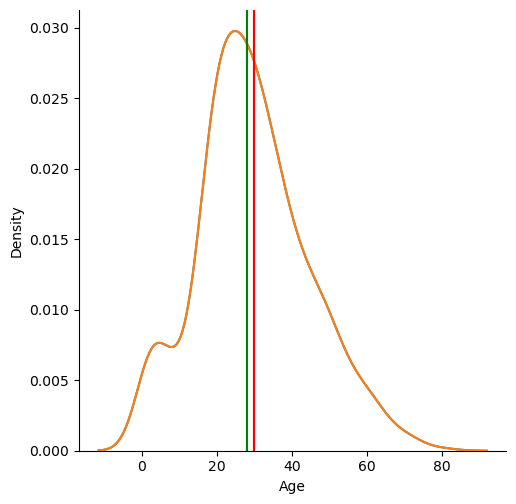

In [56]:
import warnings
warnings.filterwarnings('ignore')
sns.distplot(df['Age'],hist=False)
plt.axvline(df['Age'].mean(),color='r')
plt.axvline(df['Age'].median(),color='g')
plt.show()


In [57]:
df.Age.mean()


29.809792899408283

In [58]:
df.Age.median()

28.0

idea:
    
    group the students by class and take the mean of each Class and use it to
    replace the Age of corresponding class.
    
    eg. 
    take the mean of 1st class students and use it to impute the age of 1st class students
    only
    
    same for other classes.

in our case of titanic
we
 will group Age by 
    
    ['Pclass', 'Gender'].mean() we will use this to impute the Age of a person
    according to his pClass and Gender.


In [60]:
df["Age"] = df.groupby(["Pclass","Sex"])["Age"].apply(lambda row: row.fillna(row.mean()))

In [61]:
df.isna().sum()

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       581
Embarked      0
dtype: int64

In [62]:
df.drop('Cabin',axis=1,inplace=True)

In [63]:
df.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [68]:
plt.fiqure(figsize=(10,6))
sns.countplot(x=df.Pclass)
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'fiqure'

In [ ]:
plt.Figure

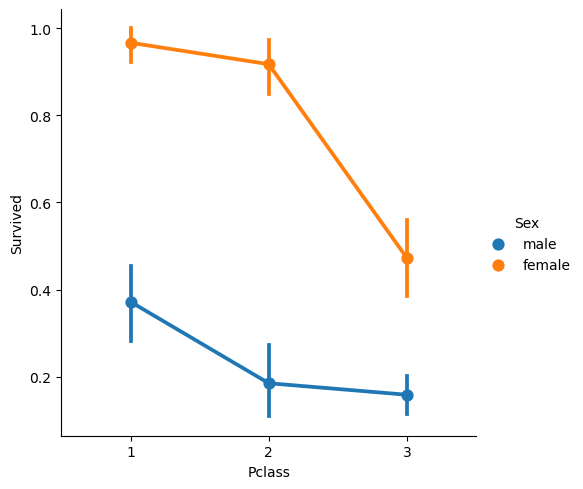

In [69]:
sns.factorplot("Pclass","Survived",hue = "Sex",data = df)
plt.show()

In [70]:
## what does the data tells you about the according to the bording location?


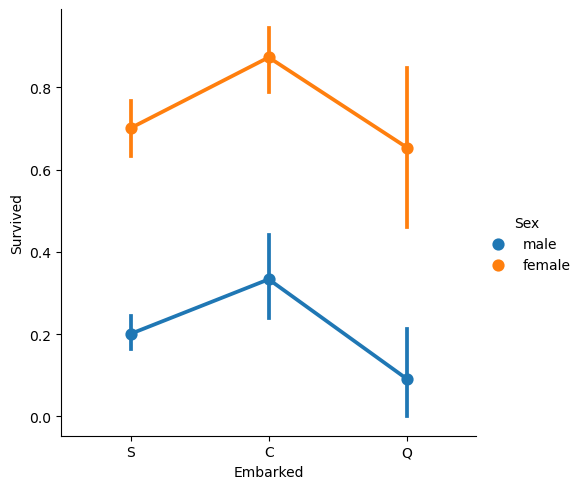

In [73]:
sns.factorplot('Embarked','Survived',hue='Sex',data=df)
plt.show()

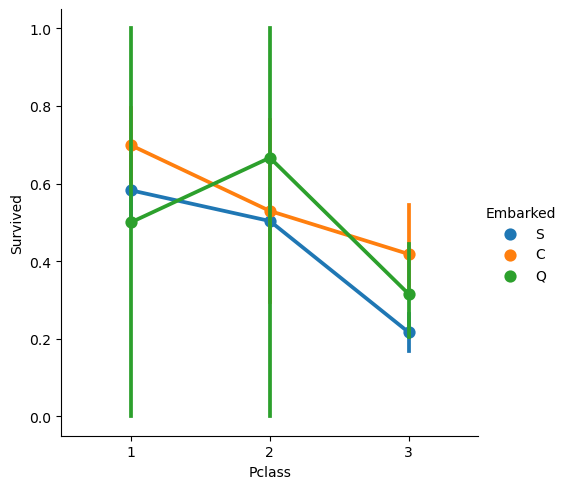

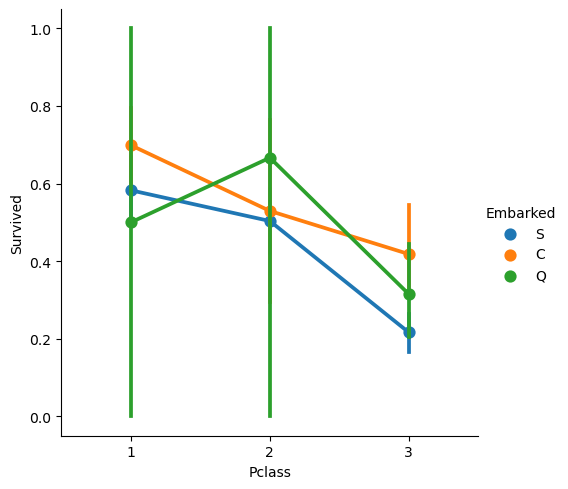

In [75]:
sns.factorplot('Pclass', 'Survived', hue = 'Embarked', data=df)
plt.show()

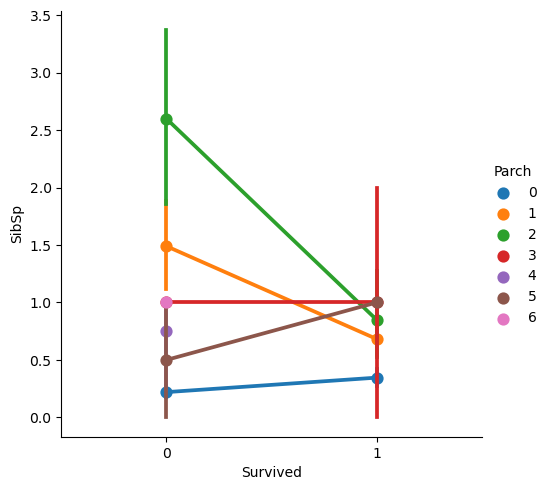

In [77]:
sns.factorplot('Survived', 'SibSp', hue = 'Parch', data=df)
plt.show()

In [76]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


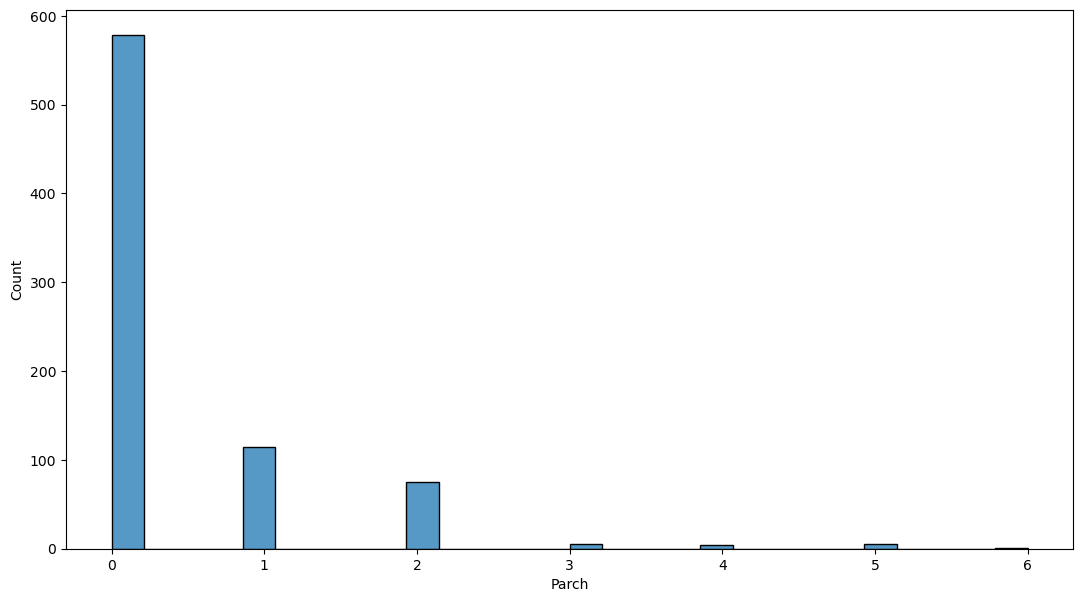

In [79]:
plt.figure(figsize=(13,7)) 
sns.histplot(df['Parch'])
plt.show()

In [80]:
#Conclusion : most people travelled alone 

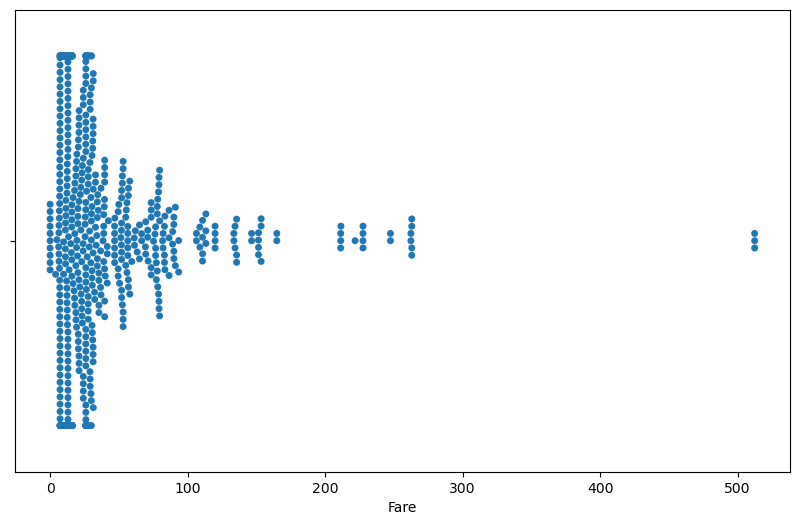

In [83]:
plt.figure(figsize = (10,6))
sns.swarmplot(x=df["Fare"])
plt.show()

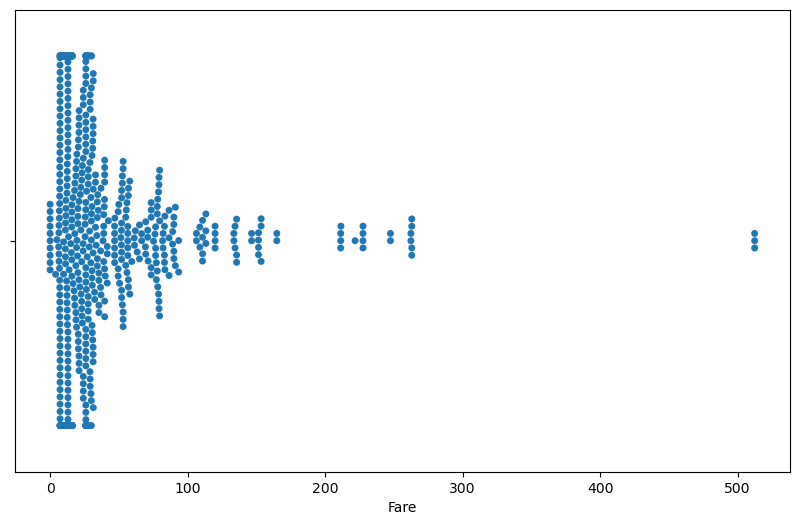

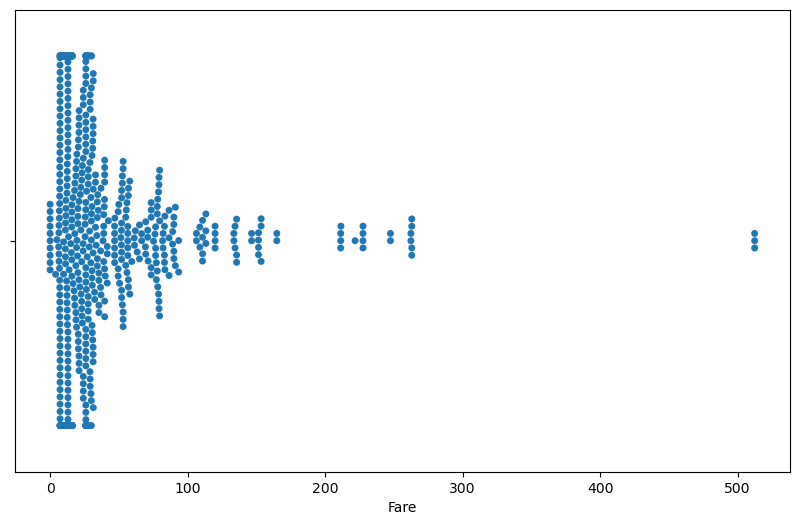

In [85]:
plt.figure(figsize=(10,6))
sns.swarmplot(x=df['Fare'],hue=df.Survived)
plt.show()
